Primeiras linhas da base:
   idade  renda_mensal  tempo_emprego  dividas_total  limite_cartao  \
0     50       4145.83            1.4           5798       13957.29   
1     40      14080.13            0.9          39607       57549.72   
2     59       7550.31           21.0           7865       20694.49   
3     27       2390.01            5.6           1340       10593.18   
4     39      17135.27           20.3          45245       77949.94   

   historico_credito  num_cartoes_credito  num_emprestimos  atraso_pagamento  \
0                  1                    1                1                 0   
1                  1                    0                2                 0   
2                  3                    4                0                 0   
3                 17                    5                3                 0   
4                  1                    3                2                 0   

  possui_imovel possui_veiculo     cargo_atual risco_credito  
0  

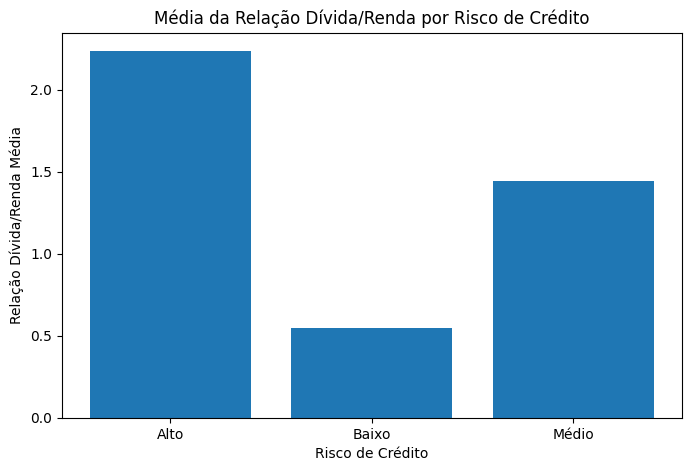


Acurácia do modelo: 96.80%

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.98      0.95      0.97       102
           1       0.98      1.00      0.99        63
           2       0.94      0.96      0.95        85

    accuracy                           0.97       250
   macro avg       0.97      0.97      0.97       250
weighted avg       0.97      0.97      0.97       250


Matriz de confusão:
[[97  0  5]
 [ 0 63  0]
 [ 2  1 82]]

Importância das variáveis:
relacao_divida_renda    0.472840
dividas_total           0.190493
atraso_pagamento        0.124743
renda_mensal            0.051995
limite_cartao           0.037384
tempo_emprego           0.029772
idade                   0.023664
historico_credito       0.021202
cargo_atual             0.015861
num_cartoes_credito     0.011225
num_emprestimos         0.010814
possui_veiculo          0.005989
possui_imovel           0.004018
dtype: float64


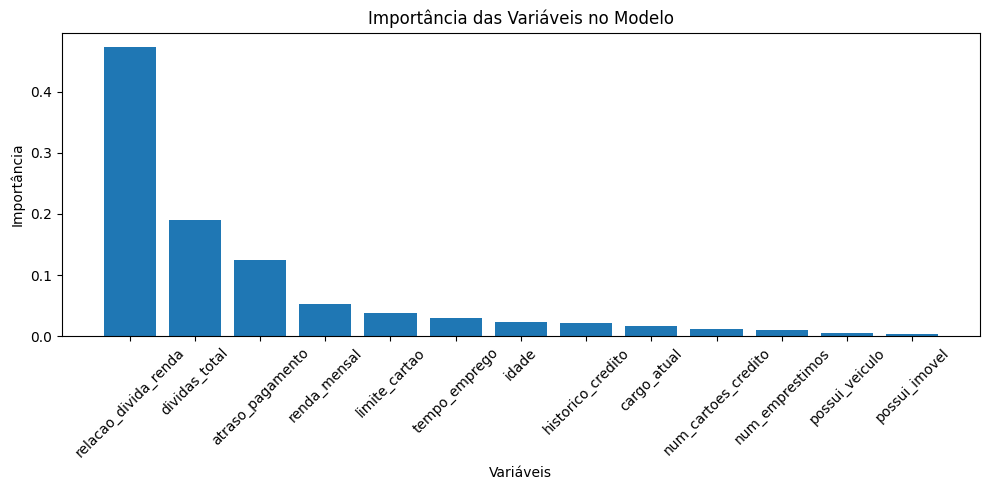


Arquivos gerados com sucesso: banco_box_tratado.csv e modelo_banco_box.pkl


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv("banco_box_sintetico.csv")

print("Primeiras linhas da base:")
print(df.head())
print("\nInformações gerais:")
df.info()
print("\nValores ausentes:")
print(df.isnull().sum())

df["renda_mensal"] = pd.to_numeric(df["renda_mensal"], errors="coerce")
df["dividas_total"] = pd.to_numeric(df["dividas_total"], errors="coerce")
df["relacao_divida_renda"] = df["dividas_total"] / df["renda_mensal"]
df = df.replace([np.inf, -np.inf], np.nan)

for coluna in df.columns:
    if df[coluna].dtype == "object":
        df[coluna] = df[coluna].fillna(df[coluna].mode()[0])
    else:
        df[coluna] = df[coluna].fillna(df[coluna].median())

df.to_csv("banco_box_tratado.csv", index=False)

media_historico = np.mean(df["historico_credito"])
print(f"\nMédia do histórico de crédito: {media_historico:.2f}")

media_risco = df.groupby("risco_credito")["relacao_divida_renda"].mean()

plt.figure(figsize=(8, 5))
plt.bar(media_risco.index, media_risco.values)
plt.title("Média da Relação Dívida/Renda por Risco de Crédito")
plt.xlabel("Risco de Crédito")
plt.ylabel("Relação Dívida/Renda Média")
plt.show()

df_modelo = df.copy()
label_encoders = {}

for coluna in df_modelo.columns:
    if df_modelo[coluna].dtype == "object":
        le = LabelEncoder()
        df_modelo[coluna] = le.fit_transform(df_modelo[coluna])
        label_encoders[coluna] = le

X = df_modelo.drop("risco_credito", axis=1)
y = df_modelo["risco_credito"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)

previsoes = modelo.predict(X_test)
acuracia = accuracy_score(y_test, previsoes)

print(f"\nAcurácia do modelo: {acuracia * 100:.2f}%")
print("\nRelatório de classificação:")
print(classification_report(y_test, previsoes))

matriz = confusion_matrix(y_test, previsoes)
print("\nMatriz de confusão:")
print(matriz)

importancias = pd.Series(modelo.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nImportância das variáveis:")
print(importancias)

plt.figure(figsize=(10, 5))
plt.bar(importancias.index, importancias.values)
plt.title("Importância das Variáveis no Modelo")
plt.xlabel("Variáveis")
plt.ylabel("Importância")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

joblib.dump(modelo, "modelo_banco_box.pkl")
print("\nArquivos gerados com sucesso: banco_box_tratado.csv e modelo_banco_box.pkl")